In [1]:
import os
os.makedirs('figures2', exist_ok=True)
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('spambase_csv.csv')
print(df.head())

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00            0.00  ...           0.00          0.0

In [3]:
# count of missing values
print(df.isnull().sum())

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [4]:
X = df.iloc[:,:57]
y = df.iloc[:,57]

In [5]:
X_Train, X_Test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
# Gaussian Naive Bayes
# scaling the features may shift the mean and variance so it is not performed
# Gaussian Naive Bayes generally does not require feature scaling because it estimates the mean and variance of each feature separately. 
# Scaling changes those values but does not fundamentally change the standardized Gaussian relationship within each feature. 
gnb = GaussianNB()
gnb.fit(X_Train, y_train)
print(f"Gaussian NB Accuracy : {accuracy_score(y_test, gnb.predict(X_Test))}")
# Calculates the posterior probability for each possible class and chooses the class with the highest posterior probability.

Gaussian NB Accuracy : 0.8208469055374593


In [ ]:
# Multinomial Naive Bayes (uses MinMax scaler so that the values are positive )
# MultinomialNB models features as counts or count-like quantities, which are naturally non-negative.
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_Train)
X_test_mm = mm_scaler.transform(X_Test)

mnb = MultinomialNB()
mnb.fit(X_train_mm, y_train)
print(f"Multinomial NB accuracy : {accuracy_score(y_test, mnb.predict(X_test_mm))}")

Multinomial NB accuracy : 0.8783930510314875


In [8]:
# Bernoulli Naive Bayes
# binarise automatically converts the values into 1/0 based on above/lesser than value 0.
bnb = BernoulliNB(binarize=0.0)
bnb.fit(X_train_mm, y_train)
print(f"Bernoulli NB Accuracy: {accuracy_score(y_test, bnb.predict(X_test_mm)):.4f}")

Bernoulli NB Accuracy: 0.8806


In [9]:
# KNN 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_Train)
X_test_scaled = scaler.transform(X_Test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print(f"KNN Accuracy: {accuracy_score(y_test, knn.predict(X_test_scaled))}")

KNN Accuracy: 0.8935939196525515


In [10]:
X_train_scaled_df = pd.DataFrame(X_train_scaled)
print("Scaled feature sample:\n", X_train_scaled_df.head())
print("\nLabel Sample:\n",y_train.head())

Scaled feature sample:
          0         1         2         3         4         5         6   \
0 -0.038442 -0.162823 -0.373284 -0.044339  0.125329 -0.017556 -0.049462   
1 -0.341222 -0.162823 -0.550609 -0.044339 -0.452760 -0.344394 -0.297595   
2 -0.341222 -0.162823  4.237186 -0.044339 -0.452760 -0.344394 -0.297595   
3 -0.341222 -0.162823 -0.550609 -0.044339  1.489025 -0.344394  3.314125   
4 -0.341222 -0.162823 -0.550609 -0.044339 -0.452760 -0.344394 -0.297595   

         7         8         9   ...        47        48        49        50  \
0 -0.258224  0.374144  0.078402  ... -0.117147 -0.157562 -0.008704 -0.173307   
1 -0.258224 -0.319925 -0.375564  ... -0.117147  0.345899 -0.061185 -0.173307   
2 -0.258224  0.666383 -0.375564  ... -0.117147 -0.157562  0.708530 -0.173307   
3  2.960258  4.465493  1.675109  ... -0.117147 -0.157562 -0.495024 -0.173307   
4 -0.258224 -0.319925 -0.375564  ... -0.117147 -0.157562 -0.495024 -0.173307   

         51        52        53        54   

In [ ]:
# pipeline bundles preprocessing and ml model into a single object 
pipeline = Pipeline([
    ('scaler', StandardScaler()), #scales to unit variance, a feature with a large numerical range can dominate this calculation.
    ('knn', KNeighborsClassifier())
])
# pipeline also prevents data leakage during cross-validation by ensuring StandardScaler only fits on the training folds 
# and transforms the validation fold during each split.
random_param_dist = {
    'knn__n_neighbors': range(1, 40, 2),          # odd numbers so there is no majority ties 
    'knn__weights': ['uniform', 'distance'],      # standard voting vs weight by distance
    'knn__metric': ['euclidean', 'manhattan']     # distance calculation metrics
}

random_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=random_param_dist, 
    n_iter=15, #randomly picks and tests 15 unique combos for hyperparameters
    cv=5, 
    scoring='accuracy', 
    random_state=42, 
    n_jobs=-1 # for faster computation 
)

random_search.fit(X_Train, y_train)
print("Best Random Search Params:", random_search.best_params_)


Best Random Search Params: {'knn__weights': 'distance', 'knn__n_neighbors': 9, 'knn__metric': 'manhattan'}


In [12]:
# grid search checks adjacent options to the best n_neighbors from the randomizedSearch 
grid_param_space = {
    'knn__n_neighbors': [7, 8, 9, 10, 11], 
    'knn__weights': [random_search.best_params_['knn__weights']],
    'knn__metric': [random_search.best_params_['knn__metric']]
}

# Run the grid search (checks every single possible combination)
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=grid_param_space, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(X_Train, y_train)
print("Absolute Best Grid Params:", grid_search.best_params_)


Absolute Best Grid Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}


In [13]:
# predict using the absolute best configuration
final_model = grid_search.best_estimator_
test_accuracy = final_model.score(X_Test, y_test)

print(f"Final Optimized KNN Accuracy: {test_accuracy * 100:.2f}%")


Final Optimized KNN Accuracy: 91.53%


In [14]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# helper to calculate metrics
def evaluate(model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    
    start = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - start
    
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    roc_auc = roc_auc_score(y_te, y_prob)
    return acc, prec, rec, f1, roc_auc, train_time, pred_time, y_pred, y_prob

# re-evaluate naive bayes models to get all metrics including time 
gnb_res = evaluate(GaussianNB(), X_Train, y_train, X_Test, y_test)
mnb_res = evaluate(MultinomialNB(), X_train_mm, y_train, X_test_mm, y_test)
bnb_res = evaluate(BernoulliNB(binarize=0.0), X_train_mm, y_train, X_test_mm, y_test)

nb_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    'Gaussian': [gnb_res[0], gnb_res[1], gnb_res[2], gnb_res[3], gnb_res[4]],
    'Multinomial': [mnb_res[0], mnb_res[1], mnb_res[2], mnb_res[3], mnb_res[4]],
    'Bernoulli': [bnb_res[0], bnb_res[1], bnb_res[2], bnb_res[3], bnb_res[4]]
})
print("Naïve Bayes Comparison:")
print(nb_table)


Naïve Bayes Comparison:
      Metric  Gaussian  Multinomial  Bernoulli
0   Accuracy  0.820847     0.878393   0.880565
1  Precision  0.719298     0.945513   0.904624
2     Recall  0.946154     0.756410   0.802564
3         F1  0.817276     0.840456   0.850543
4    ROC-AUC  0.941863     0.959810   0.956903


In [15]:
# comparison KDTree and BallTree
kdtree = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree')
balltree = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree')

kd_res = evaluate(kdtree, X_train_scaled, y_train, X_test_scaled, y_test)
ball_res = evaluate(balltree, X_train_scaled, y_train, X_test_scaled, y_test)

tree_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Training Time', 'Prediction Time'],
    'KDTree': [kd_res[0], kd_res[5], kd_res[6]],
    'BallTree': [ball_res[0], ball_res[5], ball_res[6]]
})
print("\nKDTree vs BallTree:")
print(tree_table)



KDTree vs BallTree:
            Metric    KDTree  BallTree
0         Accuracy  0.893594  0.893594
1    Training Time  0.033870  0.032230
2  Prediction Time  0.206087  0.253796


In [16]:
# evaluate KNN with varying k
k_values = [1, 3, 5, 7, 9, 11]
knn_metrics = []
for k in k_values:
    res = evaluate(KNeighborsClassifier(n_neighbors=k), X_train_scaled, y_train, X_test_scaled, y_test)
    knn_metrics.append([k, res[0], res[1], res[2], res[3]])

knn_table = pd.DataFrame(knn_metrics, columns=['k', 'Accuracy', 'Precision', 'Recall', 'F1'])
print("\nKNN Comparison:")
print(knn_table)



KNN Comparison:
    k  Accuracy  Precision    Recall        F1
0   1  0.893594   0.874359  0.874359  0.874359
1   3  0.891422   0.883598  0.856410  0.869792
2   5  0.893594   0.898907  0.843590  0.870370
3   7  0.894680   0.912676  0.830769  0.869799
4   9  0.889251   0.904494  0.825641  0.863271
5  11  0.896851   0.917847  0.830769  0.872140


In [ ]:
# a helper function that automatically splits your dataset into k equal parts (folds)
# trains the model on k-1 folds, and tests it on the remaining fold k times.
from sklearn.model_selection import cross_val_score

# best naive bayes based on accuracy
cv_nb = cross_val_score(GaussianNB(), X_Train, y_train, cv=5)
cv_knn = cross_val_score(final_model, X_Train, y_train, cv=5)

cv_table = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5, 'Average'],
    'Naïve Bayes': list(cv_nb) + [cv_nb.mean()], # creates a list of the accuracy scores and adds the mean 
    'Best KNN': list(cv_knn) + [cv_knn.mean()]
})
print("\nCross Validation (K=5):")
print(cv_table)



Cross Validation (K=5):
      Fold  Naïve Bayes  Best KNN
0        1     0.824728  0.934783
1        2     0.794837  0.914402
2        3     0.815217  0.927989
3        4     0.831522  0.932065
4        5     0.828804  0.922554
5  Average     0.819022  0.926359


In [18]:
# Grid Search vs Randomized Search Table
search_table = pd.DataFrame({
    'Parameter': ['Best k', 'Metric', 'Weights', 'Algorithm', 'CV Accuracy', 'Execution Time'],
    'GridSearchCV': [
        grid_search.best_params_['knn__n_neighbors'],
        grid_search.best_params_['knn__metric'],
        grid_search.best_params_['knn__weights'],
        'auto',
        grid_search.best_score_,
        grid_search.cv_results_['mean_fit_time'][grid_search.best_index_] + grid_search.cv_results_['mean_score_time'][grid_search.best_index_]
    ],
    'RandomizedSearchCV': [
        random_search.best_params_['knn__n_neighbors'],
        random_search.best_params_['knn__metric'],
        random_search.best_params_['knn__weights'],
        'auto',
        random_search.best_score_,
        random_search.cv_results_['mean_fit_time'][random_search.best_index_] + random_search.cv_results_['mean_score_time'][random_search.best_index_]
    ]
})
print("\nGrid Search vs Randomized Search:")
print(search_table)



Grid Search vs Randomized Search:
        Parameter GridSearchCV RandomizedSearchCV
0          Best k           11                  9
1          Metric    manhattan          manhattan
2         Weights     distance           distance
3       Algorithm         auto               auto
4     CV Accuracy     0.926359           0.922826
5  Execution Time     0.083086           0.120393


In [19]:
# theoretical Time Complexity Table
theoretical_complexity = pd.DataFrame({
    'Algorithm': ['Naïve Bayes', 'KNN (Brute)', 'KDTree', 'BallTree'],
    'Training': ['O(nd)', 'O(1)', 'O(nlog n)', 'O(nlog n)'],
    'Prediction': ['O(d)', 'O(nd)', 'O(log n)avg', 'O(log n)avg']
})
print("\nTheoretical Time Complexity:")
print(theoretical_complexity)



Theoretical Time Complexity:
     Algorithm   Training   Prediction
0  Naïve Bayes      O(nd)         O(d)
1  KNN (Brute)       O(1)        O(nd)
2       KDTree  O(nlog n)  O(log n)avg
3     BallTree  O(nlog n)  O(log n)avg


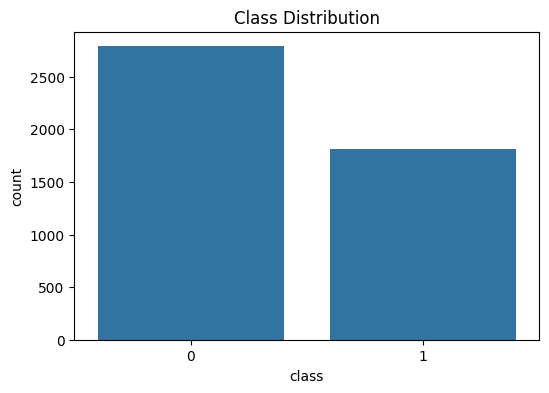

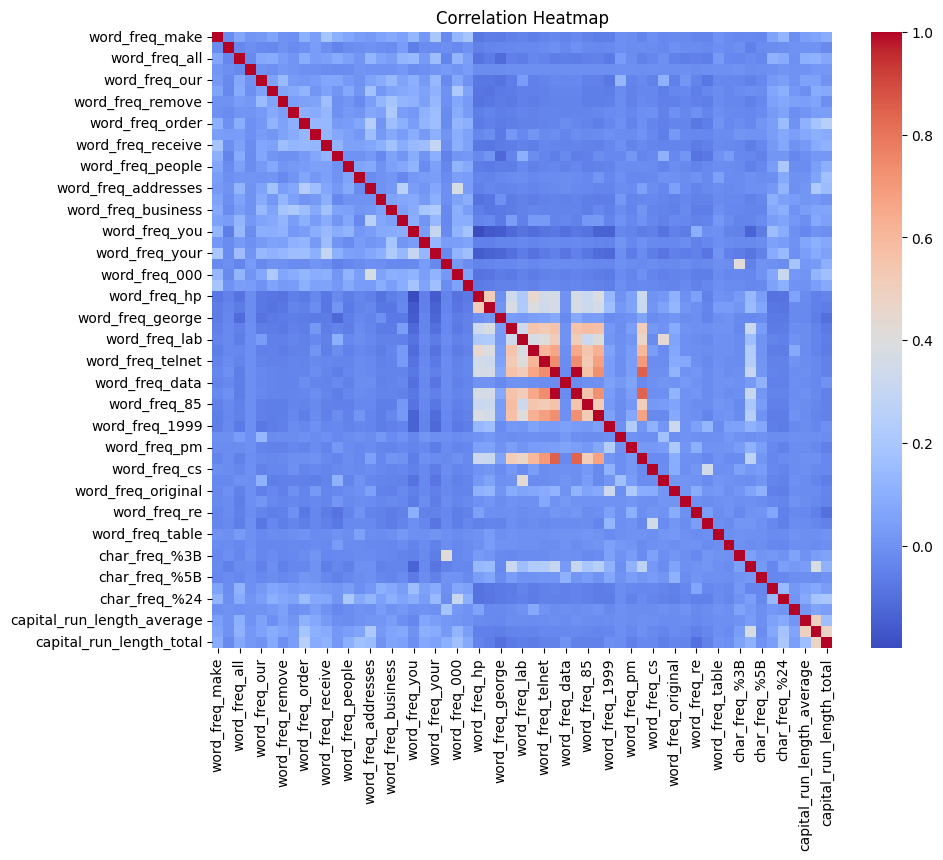

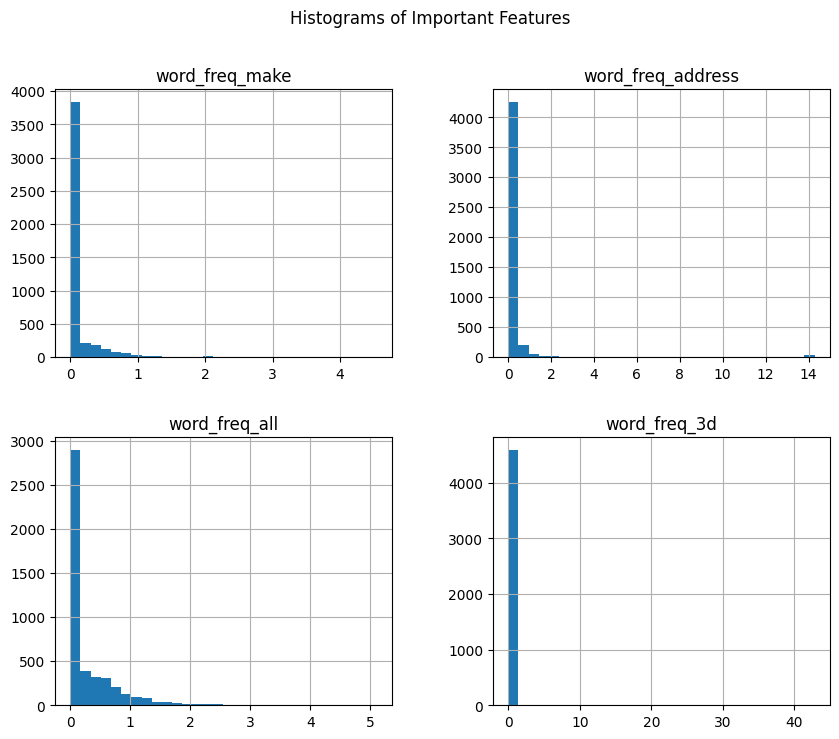

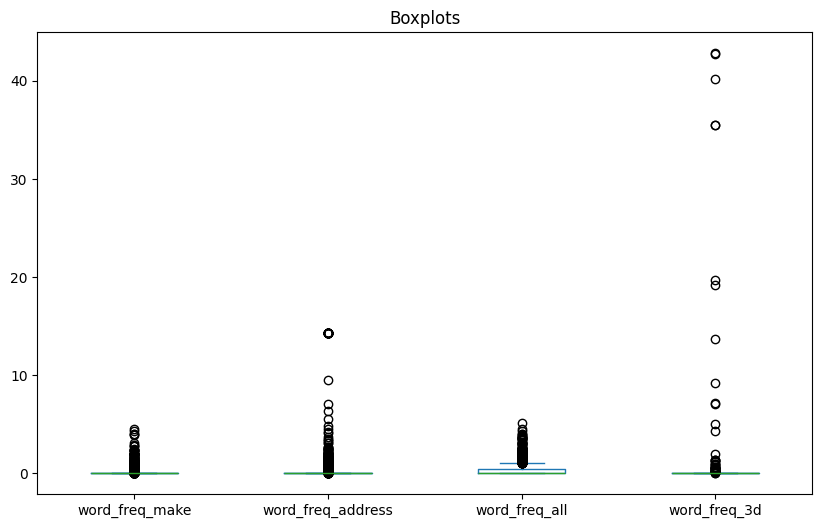

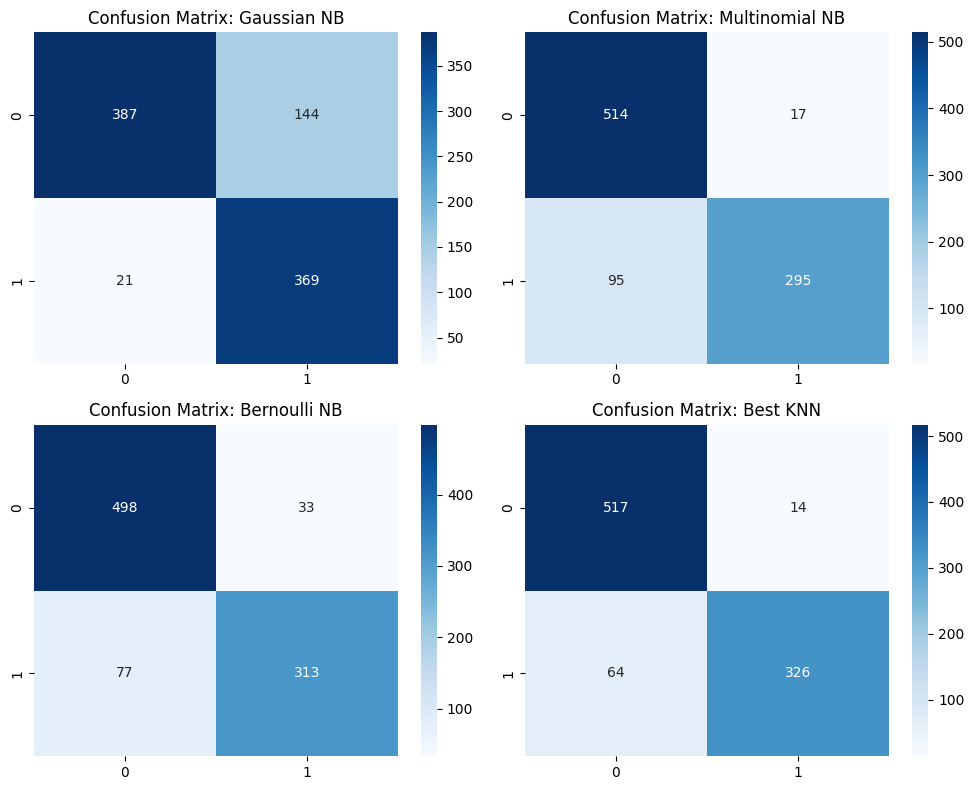

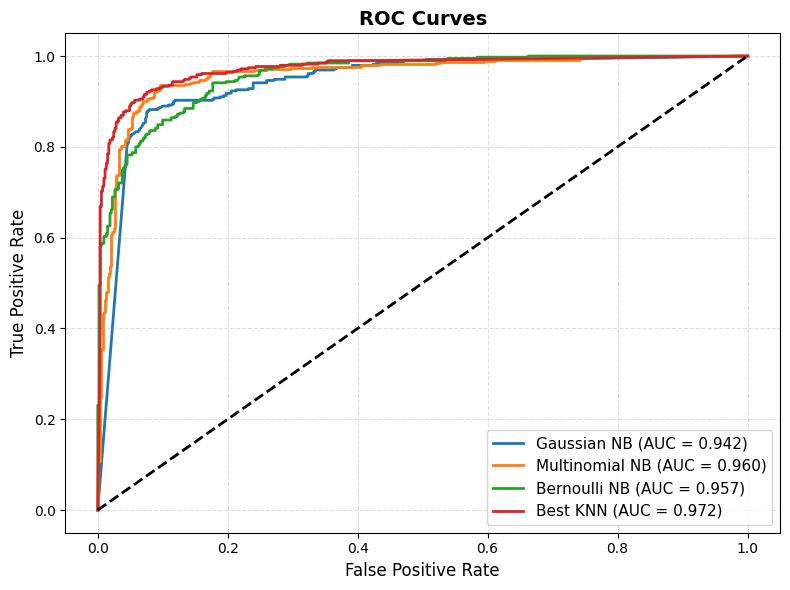

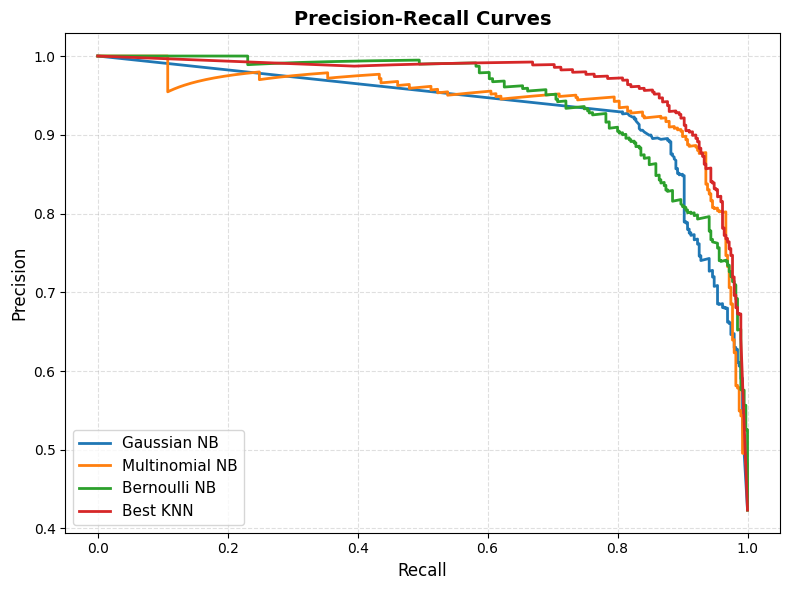

In [20]:
# Plots
 
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Class Distribution')
plt.savefig('figures2/class_distribution.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('figures2/correlation_heatmap.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# Histograms of important features
X.iloc[:, :4].hist(bins=30, figsize=(10, 8))
plt.suptitle('Histograms of Important Features')
plt.savefig('figures2/feature_histograms.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# Boxplots
X.iloc[:, :4].plot(kind='box', figsize=(10, 6))
plt.title('Boxplots')
plt.savefig('figures2/boxplots.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# Confusion matrix for each model
best_knn_res = evaluate(final_model, X_train_scaled, y_train, X_test_scaled, y_test)
models_preds = {
    'Gaussian NB': gnb_res[7],
    'Multinomial NB': mnb_res[7],
    'Bernoulli NB': bnb_res[7],
    'Best KNN': best_knn_res[7]
}
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, pred) in zip(axes.flatten(), models_preds.items()):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {name}')
plt.tight_layout()
plt.savefig('figures2/confusion_matrices.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# ROC curves to find the balance between catching true positives and avoiding false alarms
fig, ax = plt.subplots(figsize=(8, 6))
models_probs = {
    'Gaussian NB': gnb_res[8],
    'Multinomial NB': mnb_res[8],
    'Bernoulli NB': bnb_res[8],
    'Best KNN': best_knn_res[8]
}
for name, prob in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.savefig('figures2/confusion_matrices.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, prob in models_probs.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax.plot(rec, prec, linewidth=2, label=f'{name}')
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.legend(loc='lower left', fontsize=11)
ax.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.savefig('figures2/confusion_matrices.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

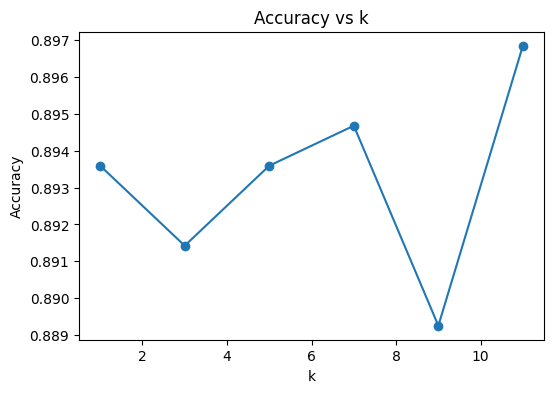

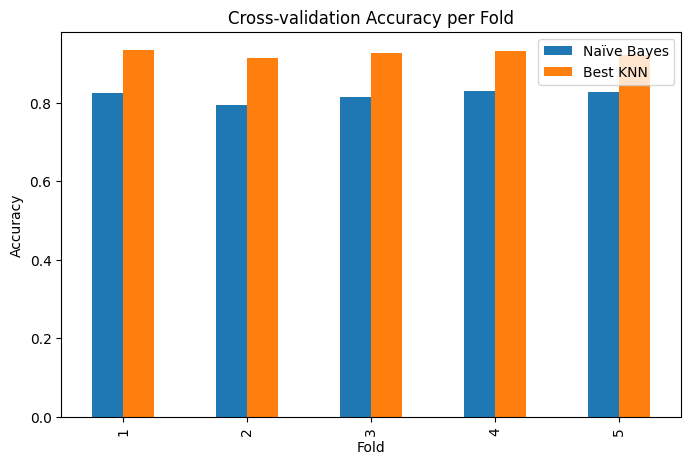


Experimental Time Analysis:


,Algorithm,Training(s),Prediction(s)
0,Gaussian NB,0.0079,0.0020
1,Multinomial NB,0.0020,0.0000
2,Bernoulli NB,0.0040,0.0021
3,Best KNN,0.0121,0.0719


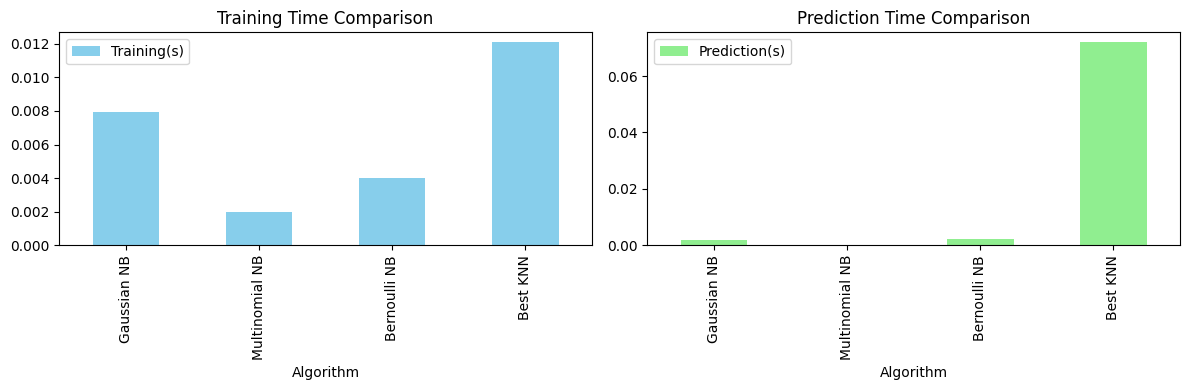

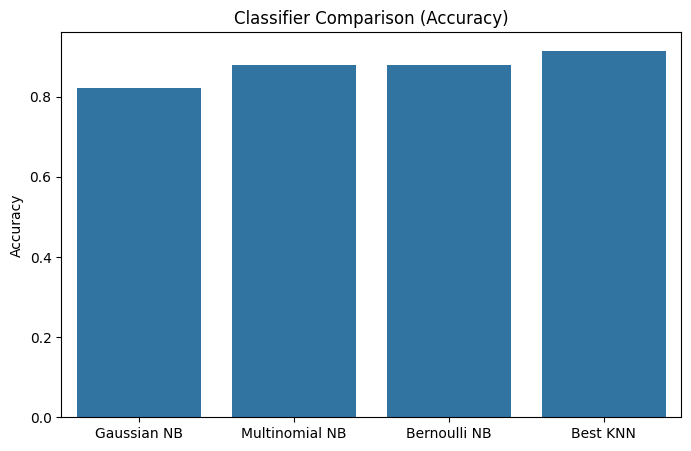

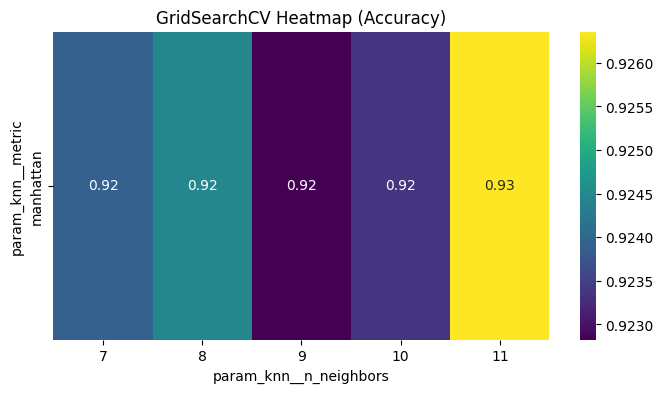

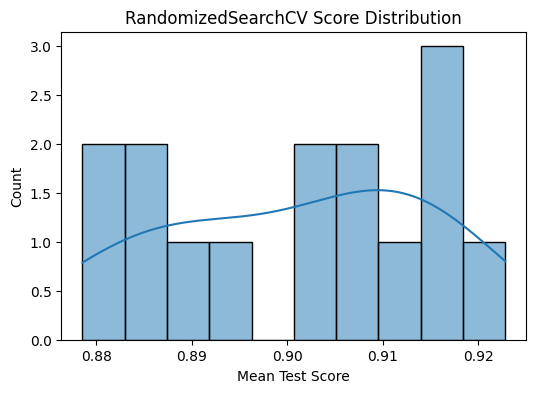

In [21]:
# Accuracy vs k
plt.figure(figsize=(6,4))
plt.plot(knn_table['k'], knn_table['Accuracy'], marker='o')
plt.title('Accuracy vs k')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.savefig('figures2/accuracy_vs_k.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# Cross-validation accuracy
cv_table.iloc[:-1].plot(x='Fold', y=['Naïve Bayes', 'Best KNN'], kind='bar', figsize=(8, 5))
plt.title('Cross-validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.savefig('figures2/cv_accuracy.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# Training time comparison & Prediction time comparison
times = pd.DataFrame({
    'Algorithm': ['Gaussian NB', 'Multinomial NB', 'Bernoulli NB', 'Best KNN'],
    'Training(s)': [gnb_res[5], mnb_res[5], bnb_res[5], best_knn_res[5]],
    'Prediction(s)': [gnb_res[6], mnb_res[6], bnb_res[6], best_knn_res[6]]
})
print('\nExperimental Time Analysis:')
display(times.round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
times.plot(x='Algorithm', y='Training(s)', kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Training Time Comparison')
times.plot(x='Algorithm', y='Prediction(s)', kind='bar', ax=ax[1], color='lightgreen')
ax[1].set_title('Prediction Time Comparison')
plt.tight_layout()
plt.savefig('figures2/time_comparison.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# Classifier comparison bar chart
accuracies = [gnb_res[0], mnb_res[0], bnb_res[0], best_knn_res[0]]
plt.figure(figsize=(8, 5))
sns.barplot(x=['Gaussian NB', 'Multinomial NB', 'Bernoulli NB', 'Best KNN'], y=accuracies)
plt.title('Classifier Comparison (Accuracy)')
plt.ylabel('Accuracy')
plt.savefig('figures2/classifier_comparison.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# GridSearchCV heatmap
# To visualize grid search, we can pivot mean_test_score on n_neighbors and metric (for fixed weights)
grid_results = pd.DataFrame(grid_search.cv_results_)
# Filter for best weight to make it 2D
best_weight = grid_search.best_params_['knn__weights']
subset = grid_results[grid_results['param_knn__weights'] == best_weight]
pivot_table = subset.pivot(index='param_knn__metric', columns='param_knn__n_neighbors', values='mean_test_score')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_table, annot=True, cmap='viridis')
plt.title('GridSearchCV Heatmap (Accuracy)')
plt.savefig('figures2/gridsearch_heatmap.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

# 14. RandomizedSearchCV score distribution
plt.figure(figsize=(6, 4))
sns.histplot(random_search.cv_results_['mean_test_score'], bins=10, kde=True)
plt.title('RandomizedSearchCV Score Distribution')
plt.xlabel('Mean Test Score')
plt.savefig('figures2/randomsearch_distribution.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

